<img src="albumenation.jpg" />

<div dir="rtl" align="right">
<b>استيراد المكتبات</b><br>
نستورد مكتبة <code>albumentations</code> وهي مكتبة متخصصة لتحسين البيانات (Data Augmentation)، و<code>cv2</code> لقراءة الصور، و<code>matplotlib</code> لعرضها.<br>
تُستخدم Data Augmentation لتوليد نسخ معدّلة من الصور لتكبير حجم مجموعة بيانات التدريب وتحسين تعميم النموذج.
</div>

In [46]:
import albumentations as A
import cv2
import matplotlib.pyplot as plt

In [28]:
#!pip install albumentations

<div dir="rtl" align="right">
<b>تعريف تحويلات Data Augmentation</b><br>
نعرّف خطّين للتحويل باستخدام <code>A.Compose()</code> الذي يُطبّق قائمة من التحويلات بالتسلسل:<br><br>
— <b>transform</b> (التحويل الأول):<br>
&nbsp;&nbsp;• <code>RandomCrop(256×256)</code>: اقتصاص عشوائي بحجم 256×256 بكسل.<br>
&nbsp;&nbsp;• <code>HorizontalFlip(p=0.5)</code>: قلب أفقي بنسبة احتمال 50%.<br>
&nbsp;&nbsp;• <code>RandomBrightnessContrast(p=0.2)</code>: تغيير عشوائي للسطوع والتباين بنسبة 20%.<br><br>
— <b>transform2</b> (التحويل الثاني):<br>
&nbsp;&nbsp;• <code>RGBShift</code>: إزاحة عشوائية لقيم قنوات R وG وB بحد أقصى ±30.<br>
&nbsp;&nbsp;• <code>HorizontalFlip(p=0.5)</code>: قلب أفقي بنسبة 50%.<br>
&nbsp;&nbsp;• <code>RandomBrightnessContrast(p=0.2)</code>: تغيير عشوائي للسطوع والتباين.
</div>

In [67]:
transform = A.Compose([
    A.RandomCrop(width=256, height=256),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
])

transform2 =  A.Compose([
    A.RGBShift(r_shift_limit=70,g_shift_limit=30, b_shift_limit=90,always_apply=False, p=0.5),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
])

C:\Users\admin\AppData\Local\Temp\ipykernel_24528\1604557289.py:8: UserWarning: Argument(s) 'always_apply' are not valid for transform RGBShift
  A.RGBShift(r_shift_limit=70,g_shift_limit=30, b_shift_limit=90,always_apply=False, p=0.5),


<div dir="rtl" align="right">
<b>قراءة الصورة وتحويلها إلى RGB</b><br>
نقرأ الصورة ونحوّلها مباشرةً من BGR إلى RGB، لأن مكتبة <code>albumentations</code> تتوقع الصور بنظام RGB وليس BGR.
</div>

In [68]:
image = cv2.imread("flowers.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

<div dir="rtl" align="right">
<b>تطبيق التحويل الأول على الصورة</b><br>
نطبّق <code>transform</code> على الصورة. تُعيد الدالة قاموساً (dictionary) نستخرج منه الصورة المحوّلة بالمفتاح <code>"image"</code>.<br>
في كل مرة يُنفَّذ هذا الكود، ستختلف النتيجة لأن التحويلات عشوائية الطبيعة.
</div>

In [69]:
transformed = transform(image=image)
transformed_image1 = transformed["image"]

<div dir="rtl" align="right">
<b>عرض الصورة بعد التحويل الأول</b><br>
نعرض الصورة بعد تطبيق الاقتصاص العشوائي والقلب الأفقي وتغيير السطوع. لاحظ أن الحجم أصبح 256×256 بكسل.
</div>

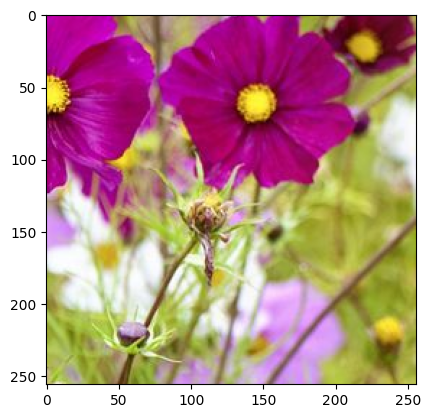

In [70]:
plt.imshow(transformed_image1)

<div dir="rtl" align="right">
<b>عرض الصورة الأصلية للمقارنة</b><br>
نعرض الصورة الأصلية (بعد تحويلها لـ RGB) للمقارنة مع نتائج التحويلات وملاحظة الفرق.
</div>

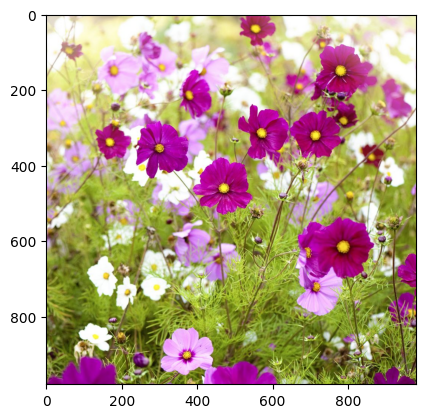

In [71]:
plt.imshow(image)

<div dir="rtl" align="right">
<b>تطبيق التحويل الثاني على الصورة</b><br>
نطبّق <code>transform2</code> الذي يُغيّر قيم قنوات الألوان RGB بشكل عشوائي بدلاً من الاقتصاص، مما يُنتج صوراً بألوان مختلفة عن الأصل مع الحفاظ على نفس الأبعاد.
</div>

In [76]:
transformed2 = transform2(image=image)
transformed_image2 = transformed2["image"]

<div dir="rtl" align="right">
<b>عرض الصورة بعد التحويل الثاني</b><br>
نعرض الصورة بعد تطبيق إزاحة الألوان (RGBShift). ستظهر الصورة بألوان مختلفة عن الأصل نتيجة تغيير قيم قنوات R وG وB بشكل عشوائي.
</div>

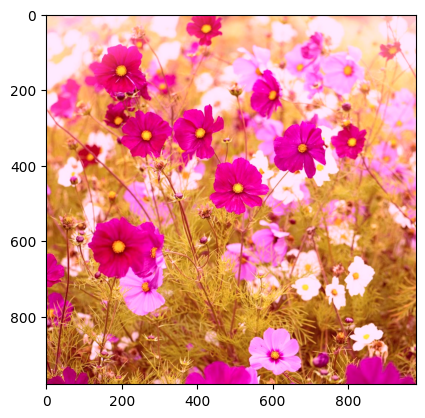

In [77]:
plt.imshow(transformed_image2)